In [20]:
import sys
sys.path.append("../..")

In [56]:
from xaikd import models, datasets, attributors


from matplotlib import pyplot as plt
import numpy as np 

In [27]:
model = models.get_model("cifar100-resnet18-p1")

In [49]:
def get_global_mean():
    
    means = dict()
    
    for layer in ["layer3", "layer4.0", "layer4.1"][1:]:
        ds = datasets.construct("cifar100", num_training_samples=50)


        loader = ds.loader(train_split=True)
        arr_act = attributors.extract_activation(
            model=model,
            layer=layer,
            dataset=ds,
            data_loader=loader,
            device="cpu",
        )

        means[layer] = arr_act.mean(axis=0)

    return means

means = get_global_mean()

[warning: num_training_samples has NO effect on cifar100


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [08:07<00:00,  1.60it/s]


[warning: num_training_samples has NO effect on cifar100


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [08:25<00:00,  1.55it/s]


In [50]:
def ano():
    
    for k, v in means.items():
        np.save(f"mean-{k}.npy", v)
ano()

In [47]:
def collection_eigvals(layer, num_samples=50, seed=1):
    ds_names = [
        "cifar100-people",
        "cifar100-vehicles_2",
        "cifar100-trees",
        "cifar100-fish"
    ]

    
    arr_eigvals = []
    np.random.seed(seed)
    
    mean = np.load(f"mean-{layer}.npy")
    for name in ds_names:
        ds = datasets.construct(name, num_training_samples=num_samples)

        loader = ds.loader(train_split=True)
        arr_act = attributors.extract_activation(
            model=model,
            layer=layer,
            dataset=ds,
            data_loader=loader,
            device="cpu",
        )
        arr_act = arr_act - mean
        
#         outer = (arr_act.T @ arr_act) / arr_act.shape[0]
#         # need to use global mean
        outer = np.cov(arr_act.T)
        
        eigvals = np.linalg.eigvalsh(outer)
        arr_eigvals.append(
            dict(layer=layer, name=name, eigvals=eigvals[::-1].copy())
        )
        
    return arr_eigvals
arr_ = collection_eigvals("layer3", num_samples=5)   

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.76it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.53it/s]


We are building `cifar100-trees` containing 5 fine classes
> maple_tree (47)
> oak_tree (52)
> palm_tree (56)
> pine_tree (59)
> willow_tree (96)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.44it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.77it/s]


We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:25<00:00,  1.56it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:26<00:00,  1.48it/s]


We are building `cifar100-trees` containing 5 fine classes
> maple_tree (47)
> oak_tree (52)
> palm_tree (56)
> pine_tree (59)
> willow_tree (96)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:25<00:00,  1.55it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:24<00:00,  1.63it/s]


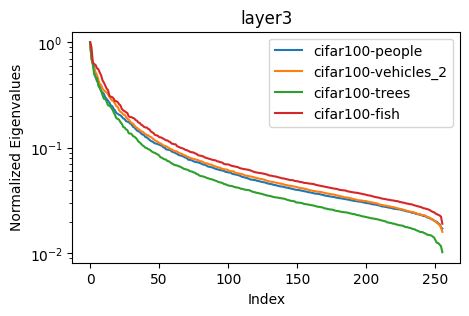

In [48]:
def viz(layer, num_samples):
 
    arr = collection_eigvals(layer, num_samples)  
    plt.figure(figsize=(5, 3))
    plt.title(f"layer={layer}; nsamples={num_samples}")
    plt.ylabel("Normalized Eigenvalues")
    plt.xlabel("Index")
    for rix, row in enumerate(arr):
        if rix == 0: 
            plt.title(row["layer"])
        name = row["name"]
        eigvals = row["eigvals"]
        eigvals /= np.max(eigvals)
        plt.plot(
            eigvals, 
            label=name
        )
    plt.legend()
    
    plt.yscale("log")
    
viz("layer3", 500)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:21<00:00,  1.89it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:24<00:00,  1.66it/s]


We are building `cifar100-trees` containing 5 fine classes
> maple_tree (47)
> oak_tree (52)
> palm_tree (56)
> pine_tree (59)
> willow_tree (96)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:23<00:00,  1.68it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:31<00:00,  1.27it/s]


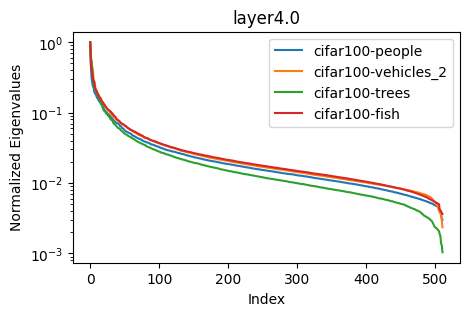

In [51]:
viz("layer4.0", 500)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:34<00:00,  1.17it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:30<00:00,  1.30it/s]


We are building `cifar100-trees` containing 5 fine classes
> maple_tree (47)
> oak_tree (52)
> palm_tree (56)
> pine_tree (59)
> willow_tree (96)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:26<00:00,  1.51it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:25<00:00,  1.59it/s]


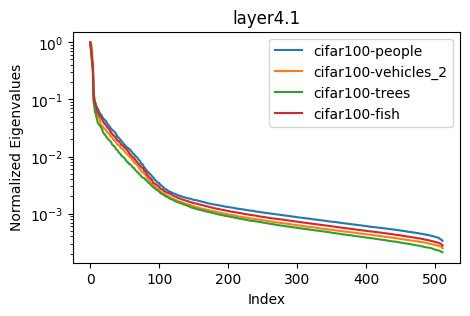

In [52]:
viz("layer4.1", 500)

# Eigenvalue Analysis

In [74]:
import pandas as pd 
from torchvision.datasets import CIFAR100
from torch.utils.data import Subset, DataLoader

df_mapping = pd.read_csv("../../xaikd/resources/cifar100-label-mapping.csv")

def get_fine_label(name):
    return df_mapping[df_mapping["coarse_label_name"] == name].fine_label.values.tolist()

In [116]:
def ano():
    
    ds = datasets.construct("cifar100-people", num_training_samples=None)
    return ds.transformation
    _ds = CIFAR100(train=True, transform=ds.transformation, root="./datasets")

    _sds = Subset(_ds, np.argwhere(np.array(_ds.targets) == 6).reshape(-1))
    _dl = DataLoader(_sds, batch_size=64)
    
    for _ in _dl:
        pass
ano()

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:28<00:00,  1.40it/s]


<0 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.77it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.81it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:23<00:00,  1.71it/s]


<0 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.77it/s]


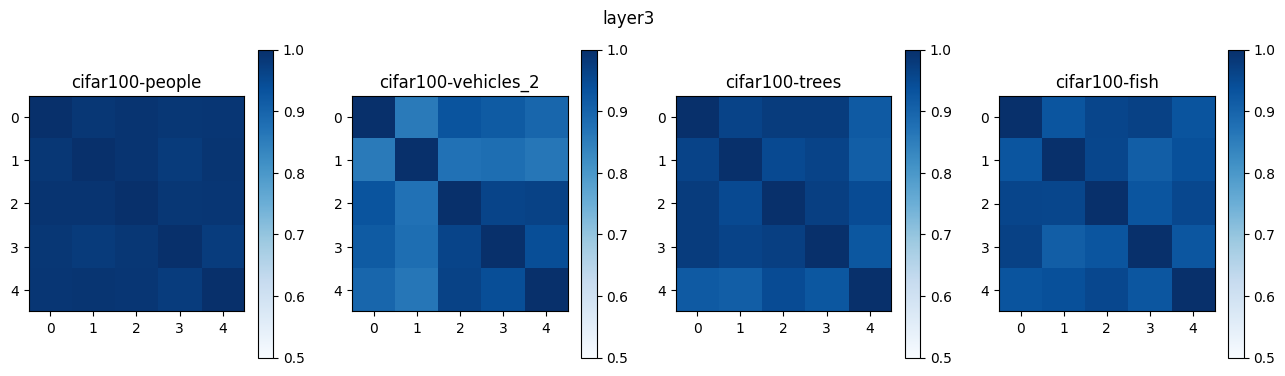

In [136]:
def eigvecs_analysis(layer):
    names = [
        "cifar100-people",
        "cifar100-vehicles_2",
        "cifar100-trees",
        "cifar100-fish"
    ]
    
    num_samples = 500
    
    ncols = len(names)
    
    plt.figure(figsize=(4*ncols, 4))
    plt.suptitle(layer)
    
    for nix, name in enumerate(names):
        plt.subplot(1, ncols, nix+1)
        plt.title(name)
        
        ds = datasets.construct(name, num_training_samples=num_samples)
        
        dl = ds.loader(train_split=True)
        arr_act = attributors.extract_activation(
            model=model,
            layer=layer,
            dataset=ds,
            data_loader=dl,
            device="cpu",
        )
        
        print("<0", (arr_act<0).sum())
        super_class_mean = np.mean(arr_act, axis=0)
        super_cov = np.cov(arr_act.T)
        _, seigvecs = np.linalg.eigh(super_cov)
        
        
        arr_eigvecs = np.zeros((arr_act.shape[1], 5))

        for fix, fine_label in enumerate(get_fine_label(name.split("-")[-1])):

            _ds = CIFAR100(train=True, transform=ds.transformation, root="./datasets")
            
            _sds = Subset(_ds, np.argwhere(np.array(_ds.targets) == fine_label).reshape(-1))

            _dl = DataLoader(_sds, batch_size=64)
            _arr_act = attributors.extract_activation(
                model=model,
                layer=layer,
                dataset=ds,
                data_loader=_dl,
                device="cpu",
            )
            
#             _arr_act = _arr_act - super_class_mean
            
            outer = (_arr_act.T  @ _arr_act ) / _arr_act.shape[0]
            _, _eigvec = np.linalg.eigh(outer)

            
            arr_eigvecs[:, fix] = _eigvec[:, -1]

            
        cosine = arr_eigvecs.T @ arr_eigvecs
        
        
        plt.imshow(np.abs(cosine), cmap="Blues", vmin=0.5, vmax=1.0)
        
        plt.colorbar()
        
eigvecs_analysis(layer="layer3")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:23<00:00,  1.69it/s]


<0 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.77it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.78it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:23<00:00,  1.70it/s]


<0 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.80it/s]


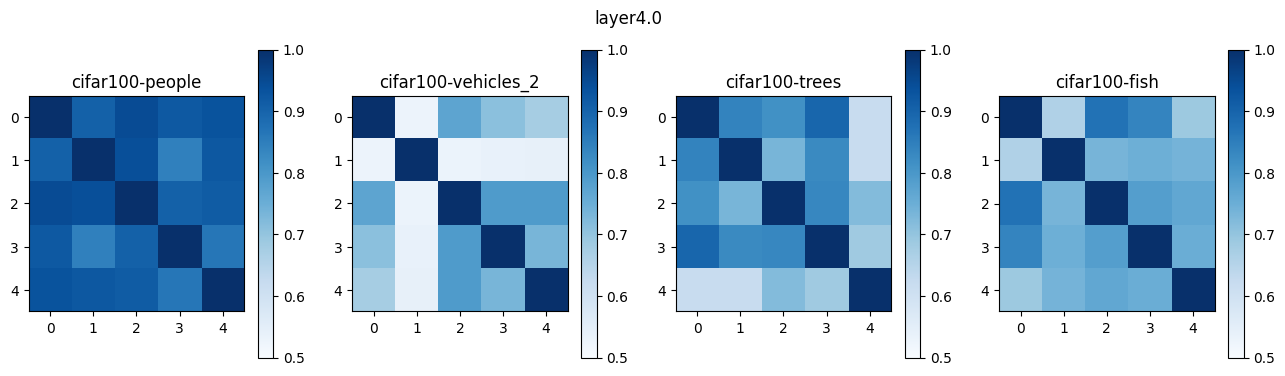

In [137]:
eigvecs_analysis(layer="layer4.0")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:32<00:00,  1.24it/s]


<0 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.74it/s]


We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.52it/s]


We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:24<00:00,  1.64it/s]


<0 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.77it/s]


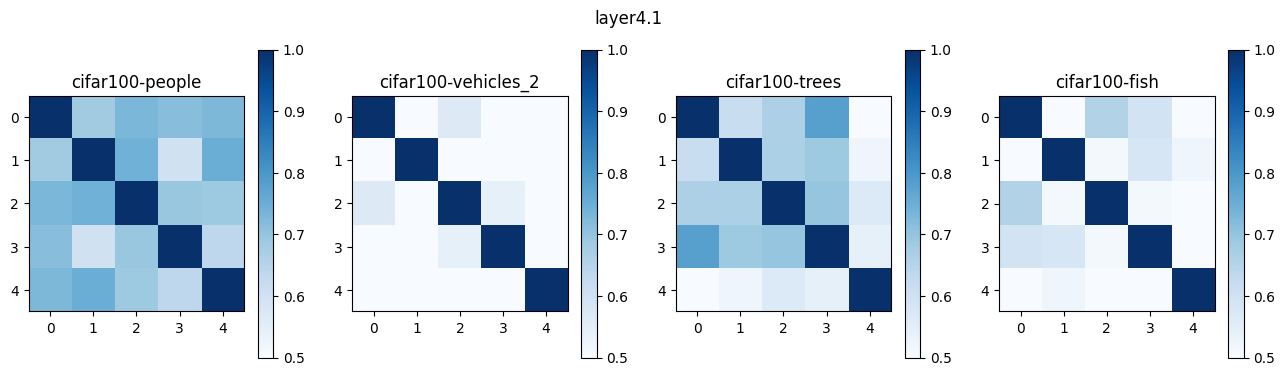

In [138]:
eigvecs_analysis(layer="layer4.1")